# GradientForest

> GradientForest

The gradient forest genomic offset [@Fitzpatrick_2014]

> ⚠️ Documentation is not complete yet!.

In [ ]:
#| default_exp GradientForest

In [ ]:
#| hide
#| export
from fastcore.utils import *
import statsmodels.api as sm
from nbdev.showdoc import *
from scipy.linalg import svd, inv
from scipy.stats import f
from TracyWidom import TracyWidom
from numba import njit, jit
from collections import namedtuple
# Rpy2
from rpy2.robjects.packages import importr
from rpy2.robjects import default_converter
from rpy2.robjects import numpy2ri
from rpy2.robjects.packages import PackageNotInstalledError
import rpy2.robjects as ro
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

A gradient forest genomic offset model has several hyperparameters: 
- `ntrees`, the number of to fit each random forest will have
- ...

> ⚠️ We haven't add the rest of hyperparameters yet!

To fit the gradient forest, we rely on on the `gradientForest` R package. 

In [ ]:
#| export
class GradientForestGO:
    "Gradient forest genomic offset statistic."
    def __init__(self, 
                 ntrees: int, # Number of  trees
                ):
        self.ntrees = ntrees
        self._gf = None
        self.F = []
        self._predictors = None
        self._base = importr('base')
        try:
            # Try loading the gradientForest package
            self._gradient_forest = importr('gradientForest')
        except PackageNotInstalledError:
            print("gradientForest package is not installed. You can install it using:")
            print('install.packages("gradientForest", repos="http://R-Forge.R-project.org")')
        except Exception as e:
            print(f"An error occurred: {e}")
    def __str__(self):
        return f"Gradient Forest genomic offset with {self.ntrees} trees."
    __repr__ = __str__

In order to use the model we have first to initialize it:  

In [ ]:
model = GradientForestGO(ntrees=100)

Then, we have to fit the model, that is ...

> ⚠️ Documentation is not complete yet!.

In [ ]:
#|export
@patch
def fit(self:GradientForestGO,
        Y: np.ndarray, # Allele frequency matrix (nxL)
        X: np.ndarray): # Environmental matrix (nxP)
    "Fits the Geometric genomic offset model. "
    n1, L = Y.shape
    n2, P = X.shape
    if n1 != n2: 
        raise ValueError("Dimensions of array don't match")
    np_cv_rules = numpy2ri.converter+default_converter
    # Use the converter within this context
    with np_cv_rules.context():
        Y_r = ro.r.matrix(np.asarray(Y), nrow=Y.shape[0])
        X_r = ro.r.matrix(np.asarray(X), nrow=X.shape[0])
        df = self._base.as_data_frame(ro.r.cbind(X_r, Y_r))
        cols = self._base.colnames(df)
        predictor_vars = cols[:X.shape[1]]
        self._gf = self._gradient_forest.gradientForest(
            df, predictor_vars=predictor_vars,
            response_vars=cols[X.shape[1]:], ntree=500
        )
        self.F = []
        for col in predictor_vars:
            dist = self._gradient_forest.cumimp_gradientForest(self._gf, col)
            dist = (np.array(dist[0]), np.array(dist[1]))
            self.F.append(dist)

The `fit()` method expects as input an genotype (or allele) matrix $\mathbf Y$ and an environmental matrix $\mathbf X$ with as many rows as individuals (or populations). For now, let us use the causal dataset we simulated in the previous section named [Simulations](simulation.html).  

In [ ]:
# If the package is intalled, the dataset 
# can be accessed with the commented code
#from genomic_offsets import datasets
#import importlib.resources 
# causal_dataset = np.load(importlib.resources.files(datasets).joinpath('causal.npz'))
causal_dataset = np.load("../genomic_offsets/datasets/causal.npz")

In [ ]:
# Read matrices
X, Xstar = causal_dataset["X"], causal_dataset["Xstar"]
Y = causal_dataset["Y"]
neglog_fitness = -np.log(causal_dataset["wstar"]+1e-5)
# Check dimensions
N, P = X.shape
assert Xstar.shape == (N, P)
assert Y.shape[0] == N

Let's split it into a train and test dataset: 

In [ ]:
rng = np.random.default_rng(1000) 
indices = rng.permutation(N)
training_idx, test_idx = indices[:60], indices[60:]
X_train, X_test = X[training_idx,:], X[test_idx,:]
Xstar_train, Xstar_test = Xstar[training_idx,:], Xstar[test_idx,:]
Y_train = Y[training_idx,:]
neglog_fitness_train, neglog_fitness_test =  neglog_fitness[training_idx], neglog_fitness[test_idx]

Let's fit the gradient forest (that is the basis of the gradient forest genomic offset model) to the training dataset. In order to do so, we first have to remove un unvariable sites: 

In [ ]:
print(f"Shape before: {Y_train.shape}")
Y_train = Y_train[:, Y_train.var(axis=0) > 0]
print(f"Shape after: {Y_train.shape}")

Shape before: (60, 219)
Shape after: (60, 204)


In [ ]:
model.fit(Y_train, X_train)

The gradient forest genomic offset metric measures the distance between the cumulative importance turnover curves under two different environmental conditions. Therefore, we can estimate such importance turnover for different values of the environmental covariates:  

In [ ]:
#| hide
#| export
@patch
def importance_turnover(self:GradientForestGO,
        x: np.ndarray, # Values of interest to interpolate
        feature_idx: int, # Environmental covariate index
        )-> np.ndarray: # Interpolated importance turnover
    if self.F is None: 
        raise ValueError("You have to fit the model first!")
    return np.interp(x, self.F[feature_idx][0], self.F[feature_idx][1])

In [ ]:
import matplotlib.pyplot as plt

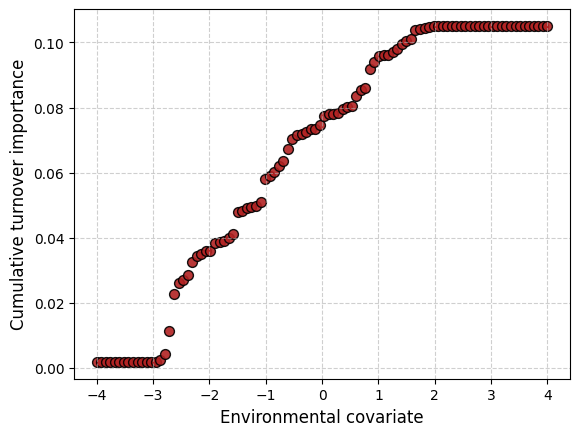

In [ ]:
env_values = np.linspace(-4, 4, 100)
turnovers = model.importance_turnover(env_values, 0)
fig, ax = plt.subplots()
scatter = ax.scatter(
    env_values,
    turnovers,
    c='firebrick', edgecolor='k',
    alpha=0.9, s=50
)
ax.set_xlabel('Environmental covariate', fontsize=12)
ax.set_ylabel('Cumulative turnover importance', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


Finally, we can predict the genomic offset under two different environments: 

In [ ]:
#| hide
@jit
def _genomic_offset_helper(F, X, Xstar):
    current_F, future_F = np.zeros(X.shape), np.zeros(X.shape)
    for feature_idx in range(X.shape[1]):
        current_F[:, feature_idx] = np.interp(
            X[:, feature_idx],
            F[feature_idx][0],
            F[feature_idx][1]
        )
        future_F[:, feature_idx] = np.interp(
            Xstar[:, feature_idx],
            F[feature_idx][0],
            F[feature_idx][1]
        )
    return current_F-future_F

In [ ]:
#| export 
@patch
def genomic_offset(self:GradientForestGO,
        X: np.ndarray, # Environmental matrix (nxP)
        Xstar: np.ndarray, # Altered environmental matrix (nxP)
           )-> np.ndarray: # A vector of genomic offsets (n)
    "Calculates the genomic offset statistic. " 
    if X.shape != Xstar.shape: 
        raise ValueError("Dimensions of array don't match")
    # Interpolate for each datapoint
    diff = _genomic_offset_helper(self.F, X, Xstar)
    return np.linalg.norm(diff, ord=2, axis=1)


As expected, the genomic offset is zero if both environmental matrixes are identical: 

In [ ]:
model.genomic_offset(X_train, X_train)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0.])

First, let's compute the (causal) training genomic offset with the RDA model and measure its association with the training negative logarithm of altered fitness:  

In [ ]:
from scipy.stats import pearsonr

In [ ]:
training_offset = model.genomic_offset(X_train, Xstar_train)
pearsonr(training_offset, neglog_fitness_train)

PearsonRResult(statistic=np.float64(0.4817056053023335), pvalue=np.float64(9.749989228734818e-05))

Finally, let's compute the (still causal) test genomic offset (that is, a measure of decrease in fitness for all individuals we did not observe their genotypes and did not use to fit the model) 

In [ ]:
testing_offset = model.genomic_offset(X_test, Xstar_test)
testing_offset

array([0.01233831, 0.05863975, 0.00036635, ..., 0.04677922, 0.01649218,
       0.02674203])

In [ ]:
pearsonr(testing_offset, neglog_fitness_test)

PearsonRResult(statistic=np.float64(0.5383720816430487), pvalue=np.float64(2.2875805480566108e-206))

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()